<a href="https://colab.research.google.com/github/JuanSamaniego02/curso-ia-para-economia/blob/main/Copia_de_3_Taller_PCA_JuanSamaniego_AlanRios2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/LinaMariaCastro/curso-ia-para-economia/blob/main/clases/4_Aprendizaje_no_supervisado/3_Taller_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)  
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)  
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

# **Taller: Creación de un Índice de Clima de Inversión con Análisis de Componentes Principales (PCA)**

**IMPORTANTE**: Guarda una copia de este notebook en tu Google Drive o computador.

**Taller en grupos de 3**

**Nombres estudiantes:**

- Juan Esteban Samaniego
- Alan Steven Rios
-

**Forma de entrega:**

- Nombrar el archivo de la siguiente forma:“Taller_PCA_apellidos.ipynb”.
- Suba el Jupyter Notebook a su cuenta en Github y envíe el link en el siguiente Forms: https://forms.cloud.microsoft/r/q1ZSe3N80C.

**IMPORTANTE:** No se recibirán talleres en Google Colab, el notebook debe estar subido en Github.

**Plazo de entrega:**

28 de abril de 2026, máximo a las 11:59 p.m. Tenga en cuenta que luego de esa hora el formulario en forms se cierra. El Jupupyter Notebook también debe quedar subido en Github antes de esa hora.

**Instrucciones Generales:**

Completa el código en las celdas marcadas con `### TU CÓDIGO AQUÍ ###`. Puedes añadir más celdas si lo requieres.

### Contexto

**Escenario:** Eres un científico de datos recién contratado como consultor experto por el **Ministerio de Comercio, Industria y Turismo (MinCIT)** de Colombia. Tu tarea principal es crear un **'Índice de Clima para la Inversión'** cuantitativo que permita clasificar y comparar el entorno competitivo de los países de América Latina y el Caribe. Este índice orientará las estrategias de integración regional y las políticas para atraer Inversión Extranjera Directa (IED).

**Objetivo:** Utilizando la base de datos de indicadores provista (preparada para este análisis) y la técnica de **Análisis de Componentes Principales (PCA)**, deberás extraer la "variable latente" que resume el clima de inversión, interpretar sus pesos económicos y presentar un ranking de países con recomendaciones ejecutivas.


## Ejercicio 1: Configuración Inicial, Carga y Exploración de Datos

1.1 Importa las librerías necesarias

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import os
from sklearn.preprocessing import StandardScaler

In [ ]:
# Configuraciones de visualización
pd.options.display.max_columns = None
pd.options.display.float_format = '{:,.2f}'.format
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

1.2 Carga el dataset "Indicators.csv" que se encuentra en el repositorio del curso, carpeta "datasets". El dataframe debe llamarse "df_indicators".

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/datasets/4_Aprendizaje_no_supervisado'
os.chdir(path)
df_indicators = pd.read_csv('Indicators.csv')

Mounted at /content/drive


In [ ]:
# Debe ser (121, 4)
print("Dimensiones del DataFrame Indicators:")
print(df_indicators.shape)

Dimensiones del DataFrame Indicators:
(121, 4)


In [ ]:
print("\nInformación general del DataFrame:")
df_indicators.info()


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CountryCode    121 non-null    object 
 1   IndicatorCode  121 non-null    object 
 2   Year           121 non-null    int64  
 3   Value          121 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.9+ KB


1.3 Carga el dataset "Country.csv" que se encuentra en el repositorio del curso, carpeta "datasets". El dataframe debe llamarse "df_countries".

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/datasets/4_Aprendizaje_no_supervisado'
os.chdir(path)
df_countries = pd.read_csv('Country.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Debe ser (14, 3)
print("Dimensiones del DataFrame Countries:")
print(df_countries.shape)

Dimensiones del DataFrame Countries:
(14, 3)


In [ ]:
print("\nInformación general del DataFrame:")
df_countries.info()


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   CountryCode  14 non-null     object
 1   ShortName    14 non-null     object
 2   Region       14 non-null     object
dtypes: object(3)
memory usage: 468.0+ bytes


### Ejercicio 2: Selección y Preparación de Datos

Para el análisis del MinCIT, hemos preseleccionado un conjunto de variables clave.

2.1. Utiliza el diccionario para modificar los códigos de los indicadores por sus descripciones

In [ ]:
nombre_indicadores = {
    'NV.AGR.TOTL.ZS': 'Agricultura (% del PIB)',
    'NE.TRD.GNFS.ZS': 'Comercio (% del PIB)',
    'NY.GDP.MKTP.KD.ZG': 'Crecimiento del PIB (%)',
    'FP.CPI.TOTL.ZG': 'Inflación (%)',
    'GC.DOD.TOTL.GD.ZS': 'Deuda del gob. central (% del PIB)',
    'SE.XPD.TOTL.GD.ZS': 'Gasto en educación (% del PIB)',
    'SH.XPD.CHEX.GD.ZS': 'Gasto en salud (% del PIB)',
    'IQ.CPA.BREG.XQ': 'Facilidad para hacer negocios',
    'IC.LGL.DURS': 'Días para cumplir contratos',
    'TX.VAL.MRCH.XD.WD': 'Exportaciones (US$)',
    'TM.VAL.MRCH.XD.WD': 'Importaciones (US$)'
}

In [ ]:
df_indicators['IndicatorCode'] = df_indicators['IndicatorCode'].map(nombre_indicadores).fillna(df_indicators['IndicatorCode'])
df_indicators.head()


,CountryCode,IndicatorCode,Year,Value
0,CHL,Agricultura (% del PIB),2014,6.75
1,CHL,Comercio (% del PIB),2014,74.31
2,CHL,Crecimiento del PIB (%),2014,7.65
3,CHL,Inflación (%),2014,12.62
4,CHL,Deuda del gob. central (% del PIB),2014,42.83


2.2. Utiliza pivot table para crear un nuevo dataframe donde se encuentren los países como filas y los indicadores como columnas. Llama a este dataframe "df_pivot". No olvides colocar .reset_index() para que la columna de código de países quede como una columna y no como el índice.

In [ ]:
df_pivot = df_indicators.pivot_table(index='CountryCode', columns='IndicatorCode', values='Value').reset_index()
df_pivot.head()

IndicatorCode,CountryCode,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%)
0,ARG,11.73,32.43,-0.45,73.07,873.48,"20,153,725,105.95",2.19,2.38,4.09,"18,058,208,718.45",44.28
1,BOL,NaN,54.39,1.76,66.69,798.96,"39,036,984,373.93",NaN,5.37,5.05,"36,977,180,000.81",36.05
2,BRA,12.79,60.18,2.59,57.20,741.68,"56,043,860,610.92",3.57,4.56,5.31,"50,026,448,161.33",25.60
3,CHL,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62
4,COL,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61


2.3. Crea el dataframe "df_final", realizando un merge entre "df_pivot" y "df_countries" con el fin de agregar el nombre de los países.

In [ ]:
df_final = pd.merge(df_pivot, df_countries, on='CountryCode', how='left')
df_final.head()

,CountryCode,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%),ShortName,Region
0,ARG,11.73,32.43,-0.45,73.07,873.48,"20,153,725,105.95",2.19,2.38,4.09,"18,058,208,718.45",44.28,Argentina,Latin America & Caribbean
1,BOL,NaN,54.39,1.76,66.69,798.96,"39,036,984,373.93",NaN,5.37,5.05,"36,977,180,000.81",36.05,Bolivia,Latin America & Caribbean
2,BRA,12.79,60.18,2.59,57.20,741.68,"56,043,860,610.92",3.57,4.56,5.31,"50,026,448,161.33",25.60,Brasil,Latin America & Caribbean
3,CHL,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62,Chile,Latin America & Caribbean
4,COL,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61,Colombia,Latin America & Caribbean


2.4. Elimina las columnas "Region" y "CountryCode" y establece la columna 'ShortName' como el índice del dataframe

In [ ]:
df_final = df_final.drop(columns=['Region', 'CountryCode'])
df_final = df_final.set_index('ShortName')
df_final.head()

,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%)
ShortName,,,,,,,,,,,
Argentina,11.73,32.43,-0.45,73.07,873.48,"20,153,725,105.95",2.19,2.38,4.09,"18,058,208,718.45",44.28
Bolivia,NaN,54.39,1.76,66.69,798.96,"39,036,984,373.93",NaN,5.37,5.05,"36,977,180,000.81",36.05
Brasil,12.79,60.18,2.59,57.20,741.68,"56,043,860,610.92",3.57,4.56,5.31,"50,026,448,161.33",25.60
Chile,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62
Colombia,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61


### Ejercicio 3: Limpieza de Datos (Imputación de Valores Faltantes)

En la vida real de un economista, los datos tienen huecos. El PCA requiere bases completas. Usaremos una estrategia de imputación por la media para resolver los NaN.

3.1. Revisa cuántos valores faltantes hay en cada columna

In [ ]:
df_final.isna().sum()

,0
Agricultura (% del PIB),4
Comercio (% del PIB),3
Crecimiento del PIB (%),0
Deuda del gob. central (% del PIB),4
Días para cumplir contratos,2
Exportaciones (US$),3
Facilidad para hacer negocios,5
Gasto en educación (% del PIB),3
Gasto en salud (% del PIB),4
Importaciones (US$),3


3.2. Para cada columna, utiliza el promedio del resto de países de Latinoamérica para imputar los valores faltantes. El resultado debe quedar en un dataframe llamado "df_final_imputed". Al final revisa que no haya quedado ningún valor faltante en las columnas del dataframe.

In [ ]:
df_final_imputed = df_final.copy()
for col in df_final_imputed.columns:
    df_final_imputed[col].fillna(df_final_imputed[col].mean(), inplace=True)
df_final_imputed.isna().sum()

/tmp/ipykernel_3519/1955982942.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final_imputed[col].fillna(df_final_imputed[col].mean(), inplace=True)


,0
Agricultura (% del PIB),0
Comercio (% del PIB),0
Crecimiento del PIB (%),0
Deuda del gob. central (% del PIB),0
Días para cumplir contratos,0
Exportaciones (US$),0
Facilidad para hacer negocios,0
Gasto en educación (% del PIB),0
Gasto en salud (% del PIB),0
Importaciones (US$),0


### Ejercicio 4: Matriz de Correlaciones y Estandarización de Variables

4.1. Grafica un mapa de calor para ver las correlaciones entre las variables.

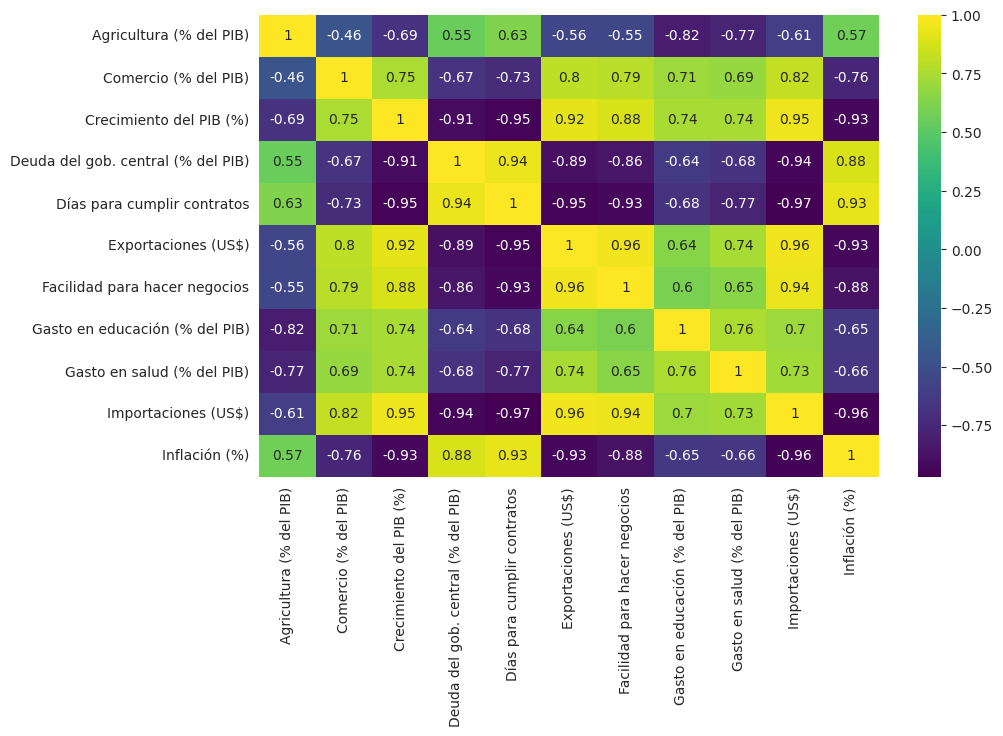

In [ ]:
corr = df_final_imputed.corr().round(2)
sns.heatmap(corr, annot=True, cmap='viridis')
plt.show()

4.2. Interpreta los resultados resaltando las correlaciones más relevantes.

Dentro de la matriz de correlacion podemos encontrar fuertes correlaciones positivas y negativas, dentro de las positivas se destacan:

* 1.Exportaciones-Crecimiento del PIB: Se muestra una correlacion de 0.92 lo que es consistente en paises como colombia que dependen de la exportacion de commodities
* 2.Importaciones-Crecimiento del PIB: Esta correlacion es consistente debido a que un aumento de las importaciones facilitan la adquisicion de maquinaria,tecologia y materias primas escenciales, potenciando la capácidad productiva. Ademas un aumento en las importaciones no relacionadfa con inversion se traduce en un aumento en el consumo

Mientras que en las negativas encontramos


* 1.Crecimiento del PIB-Días para cumplir contratos:A más demoras institucionales, menor crecimiento económico.Refleja cómo la ineficiencia jurídica afecta directamente la actividad productiva.


* 2.Exportaciones-Inflación:Mayor nivel de exportaciones se asocia con menor inflación.Puede indicar economías más competitivas y estables en precios cuando se integran al comercio exterior.




4.3. Las exportaciones están en miles de millones de dólares y el crecimiento en porcentajes de un dígito. PCA busca varianzas, por lo que estandarizar (Media 0, Desviación 1) es un paso matemático obligatorio para no sesgar el modelo hacia las variables nominales grandes.  Estandariza todas las variables del dataframe y almacena el resultado en X_scaled.

In [ ]:
X_scaled = StandardScaler().fit_transform(df_final_imputed)

### Ejercicio 5: Aplicación de PCA

Vamos a correr PCA para identificar el número de componentes. Buscamos capturar la mayor cantidad de información (varianza) con la menor cantidad de dimensiones.

5.1. Corre PCA sobre X_scaled y calcula la varianza acumulada. Almacénala en la variable "varianza_acumulada".

In [ ]:
varianza_acumulada = []
pca_simple = PCA()
pca_simple.fit(X_scaled)
varianza_acumulada = np.cumsum(pca_simple.explained_variance_ratio_)
print(varianza_acumulada)

[0.80432386 0.89486154 0.93597174 0.95991133 0.97641891 0.9864744
 0.99249496 0.99665217 0.99895635 0.99961687 1.        ]


5.2. Similar a como lo vimos en clase, grafica la varianza explicada acumulada por componente.

[[-0.24125142  0.27941045  0.32457375 -0.30918249 -0.3259168   0.32216968
   0.3112744   0.26684394  0.2768266   0.32963331 -0.31524916]
 [ 0.6150801   0.04193869  0.03967673 -0.1939408  -0.12856662  0.20972996
   0.24156214 -0.49969942 -0.38044187  0.16846499 -0.19760074]
 [ 0.35197043  0.80672081 -0.17092541  0.2859966   0.20656022  0.02279155
   0.03240282  0.22339632  0.10725555 -0.02295043  0.09019913]
 [ 0.11132056 -0.0603403  -0.17865327  0.02072245 -0.14939515  0.1745812
   0.02884758 -0.4768026   0.7859129  -0.08835127  0.21256749]
 [-0.471589    0.06982082 -0.06675378  0.52574442  0.09303397  0.19266406
   0.54842515 -0.32128684 -0.1977679  -0.0513361  -0.01865308]
 [ 0.02047605 -0.02097679 -0.16411816 -0.36878097 -0.1184254  -0.04595658
   0.48144708  0.20432057 -0.13814214 -0.03392489  0.72546372]
 [-0.25461587  0.37782225  0.51790731 -0.26027139  0.22229732 -0.33349275
  -0.14366279 -0.46261474 -0.02888492  0.04954082  0.24057927]
 [ 0.28677276 -0.16236287  0.70807821  0.4

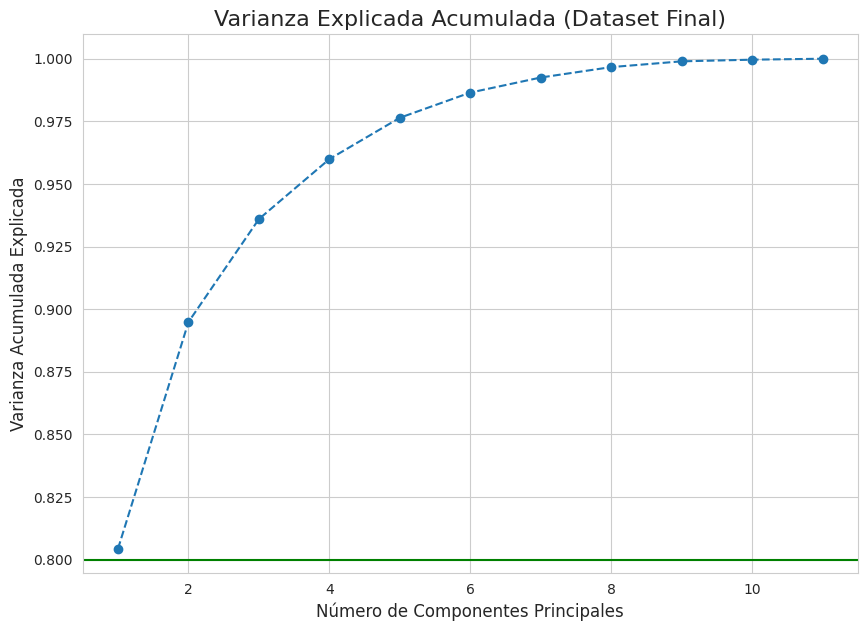

In [ ]:

print(pca_simple.components_)
print(pca_simple.explained_variance_)
varianza_acumulada_1 = np.cumsum(pca_simple.explained_variance_ratio_)

plt.figure(figsize=(10, 7))
plt.plot(range(1, len(varianza_acumulada_1) + 1), varianza_acumulada_1, marker='o', linestyle='--')
plt.title('Varianza Explicada Acumulada (Dataset Final)', fontsize=16)
plt.xlabel('Número de Componentes Principales', fontsize=12)
plt.ylabel('Varianza Acumulada Explicada', fontsize=12)
plt.axhline(y=0.8, color='g', linestyle='-', label='80% de Varianza')
plt.show()

5.3. Realiza un análisis del gráfico anterior.

En el gráfico se puede observar que el primer componente(PC1)captura más del 80% de la varianza total. Esto podría ser un indicio de que las variables ya tienen una estructura muy sólida o que las variables estan altamente correlacionados y dada las correlaciones que se hallaron, se puede decir que se trata del segundo factor. Por otra parte, el punto de Saturación de la curva lo podemos observar cuano esta comienza a aplanarse significativamente, es decir,  después del PC3 o PC4. A partir de ahí cada componente adicional aporta beneficios marginales.



### Ejercicio 6: Interpretación Económica de los Componentes (Loadings)

Nos vamos a quedar con un solo componente. Vamor a analizar qué variables originales alimentan a este componente.

6.1. Corre nuevamente el PCA, pero ahora indicando que tenga en cuenta solo 1 componente. Almacena el modelo en "pca_final" y los resultados en "X_pca".

In [ ]:
pca_final = PCA(n_components=1)
X_pca = pca_final.fit_transform(X_scaled)
print(pca_final.components_)
print(pca_final.explained_variance_)

[[-0.24125142  0.27941045  0.32457375 -0.30918249 -0.3259168   0.32216968
   0.3112744   0.26684394  0.2768266   0.32963331 -0.31524916]]
[9.52814414]


6.2. Grafica el mapa de calor de los loadings como lo vimos en clase

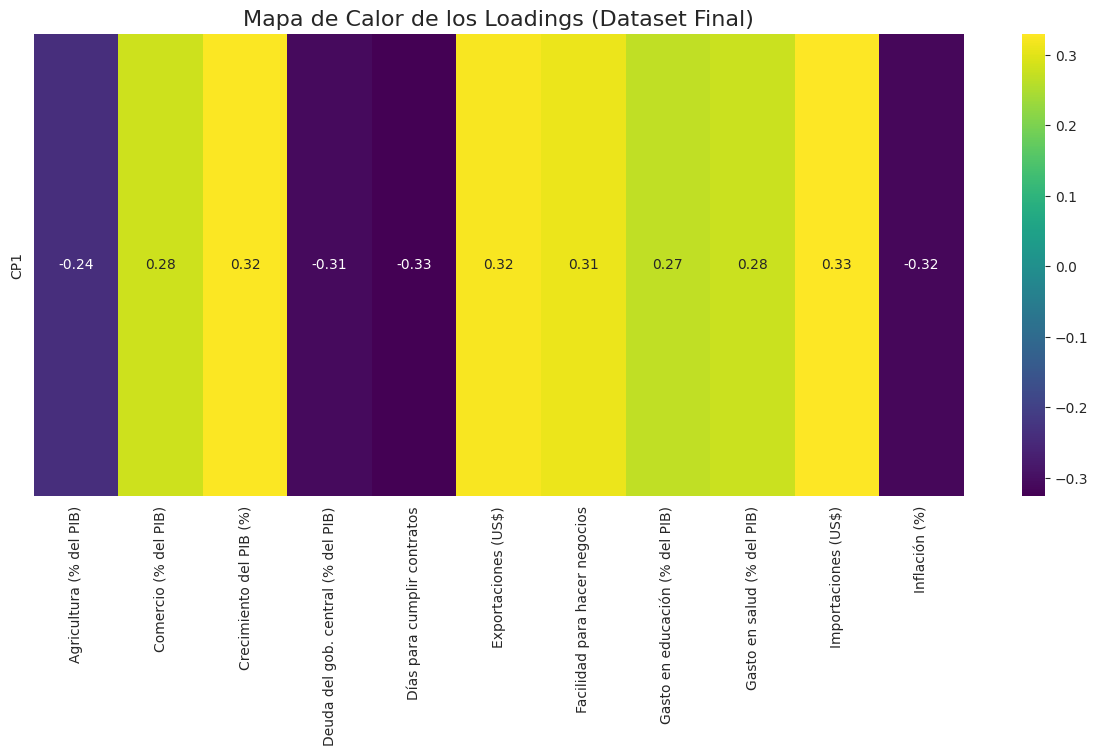

In [ ]:
df_final_loadings = pd.DataFrame(
    pca_final.components_,
    columns=df_final_imputed.columns,
    index=['CP1',])
df_final_loadings
plt.figure(figsize=(15, 6))
sns.heatmap(df_final_loadings, annot=True, cmap='viridis', fmt='.2f')
plt.title('Mapa de Calor de los Loadings (Dataset Final)', fontsize=16)
plt.show()

6.3. Realiza una interpretación de los loadings. ¿Cuáles variables tienen las cargas altas y positivas y cuáles las cargas altas y negativas? De acuerdo con este análisis, ¿consideras que efectivamente podemos utilizar el componente 1 como un índice del clima para la inversión en cada país de Latinoamérica? ¿por qué si o por qué no?

En tanto se refiere a las cargas altas y positivas se encuentran las siguientes:

* Importaciones (0.33) y Exportaciones (0.32) (Apertura comercial).

* Crecimiento del PIB (0.32) y Facilidad para hacer negocios (0.31).

* Gasto en salud (0.28), Gasto en educación (0.27) y Comercio (0.28).


Por otro lado las cargas altas y negativas son:

* Días para cumplir contratos (-0.33) (Burocracia/Ineficiencia legal).

* Inflación (-0.32) (Inestabilidad macroeconómica).

* Deuda del gobierno central (-0.31) (Riesgo fiscal).

* Agricultura % del PIB (-0.24) (Suele indicar economías menos industrializadas o diversificadas).


La utilización del CP1 como un Índice del Clima para la Inversión es una interpretación interesante que tiene una discusión profunda porque permite hacer un debate sobre sus ventajas y las desventajas que tiene, de esta manera, es coherente desde el punto de vista económico.
El componente logra sintetizar de manera lógica la tensión entre los facilitadores del mercado y los obstáculos estructurales. Por un lado, agrupa una parte importante de las variables agregadas como como el crecimiento del PIB, la apertura comercial y la facilidad para hacer negocios, con una "carga" positiva, mientras que marca con signos negativos los factores de riesgo sistémico, como la inflación, el nivel de deuda y la inseguridad jurídica (representada por los días para cumplir contratos). Además, dado que la magnitud de los loadings es notablemente uniforme (oscilando entre 0.24 y 0.33), el CP1 no está sesgado por una única variable, sino que constituye un indicador robusto de la competitividad sistémica, permitiendo calificar a los países según su capacidad para ofrecer un entorno institucional eficiente y macroeconómicamente estable.



### Ejercicio 7: Creación del 'Índice de Clima para la Inversión'

Asignaremos el CP1 como nuestro 'Índice de Clima para la Inversión' y construiremos el ranking regional.

In [ ]:
df_final_imputed['Indice_Inversion'] = X_pca[:, 0]
df_final_imputed.head()

,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%),Indice_Inversion
ShortName,,,,,,,,,,,,
Argentina,11.73,32.43,-0.45,73.07,873.48,"20,153,725,105.95",2.19,2.38,4.09,"18,058,208,718.45",44.28,-5.93
Bolivia,8.86,54.39,1.76,66.69,798.96,"39,036,984,373.93",3.96,5.37,5.05,"36,977,180,000.81",36.05,-1.93
Brasil,12.79,60.18,2.59,57.20,741.68,"56,043,860,610.92",3.57,4.56,5.31,"50,026,448,161.33",25.60,-1.24
Chile,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62,4.89
Colombia,6.92,59.96,6.60,47.95,633.90,"56,527,087,039.04",3.96,6.34,6.30,"67,424,196,254.97",11.61,2.13


7.1. Ordena el df_final por el índice de clima para la inversión de mayor a menor valor del índice.

In [ ]:
df_final_imputed = df_final_imputed.sort_values(by='Indice_Inversion', ascending=False)

7.2. Convierte 'ShortName' en una columna del dataframe.

In [ ]:
short_names = df_final_imputed.index.tolist()
df_final_imputed['ShortName'] = short_names
df_final_imputed.head()

,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%),Indice_Inversion,ShortName
ShortName,,,,,,,,,,,,,
Chile,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62,4.89,Chile
Panamá,5.80,56.08,6.89,43.42,555.93,"83,978,447,805.32",5.40,5.95,7.72,"76,338,244,613.60",8.11,3.89,Panamá
Costa Rica,8.11,70.86,5.88,58.75,610.31,"78,236,959,844.64",5.53,5.64,6.77,"72,324,083,969.39",8.49,2.75,Costa Rica
Colombia,6.92,59.96,6.60,47.95,633.90,"56,527,087,039.04",3.96,6.34,6.30,"67,424,196,254.97",11.61,2.13,Colombia
Uruguay,8.21,64.01,4.47,58.75,717.08,"63,598,148,937.21",3.96,5.63,6.65,"59,086,857,093.80",11.66,1.09,Uruguay


7.3. Utiliza un barplot para mostrar los resultados del Índice de Clima para la Inversión. En el eje y deben ir los países y en el eje X el puntaje del índice. No olvides colocar título al gráfico y a los ejes.

/tmp/ipykernel_3519/1609903707.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Indice_Inversion', y='ShortName', data=df_final_imputed, palette='viridis')


<Axes: xlabel='Indice_Inversion', ylabel='ShortName'>

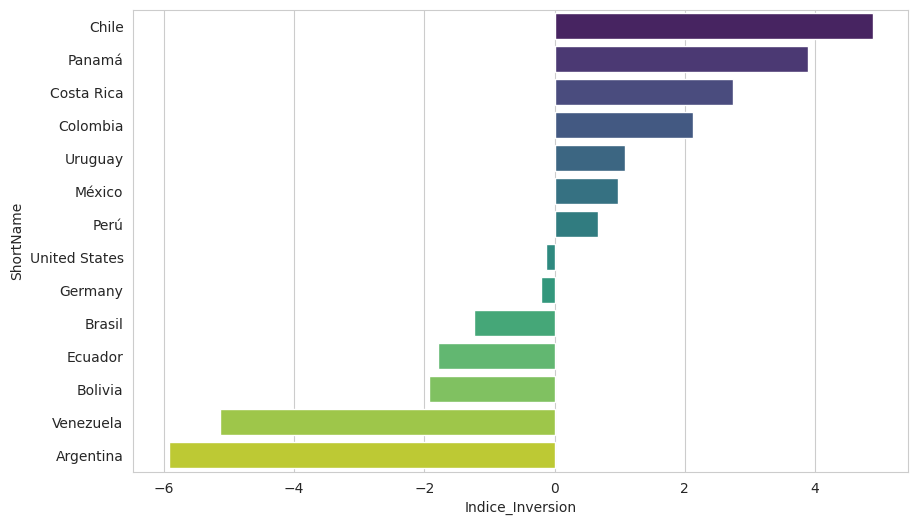

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Indice_Inversion', y='ShortName', data=df_final_imputed, palette='viridis')

7.4. Analiza los resultados del gráfico y redacta una conclusiones para el MinCIT sobre el clima de inversión en la región, quiénes son nuestros competidores en la atracción de capitales extranjeros y por qué, en qué son mejores que Colombia.

En general los resultados se comportan de tal manera que revela una brecha significativa en la competitividad regional. El Índice de Inversión muestra que Chile (4.9) lidera con una ventaja amplia, seguido por Panamá (3.9) y Costa Rica (2.8). Colombia se ubica en una posición competitiva intermedia-alta con un puntaje de 2.1, situándose por encima de economías de peso como Uruguay, México y Perú. En el extremo opuesto, Argentina y Venezuela presentan el clima más desfavorable para el capital extranjero, con puntajes negativos extremos. Sin emabargo, teniendo un análisis más robusto los competidores directos en la atracción de Capital serían: Chile, Panamá y Costa Rica. Esto sucede por diversas razones tanto económicas como políticas dentro de las cuales destacan la eficiencia institucional, la estabilidad en las reglas de juego, facilidad de comercio entre otras.
Teniendo en cuenta todo lo anterior para el MinCIT si quiere escalar posiciones frente a Chile, Panamá y Costa Rica, la política pública debe priorizar la facilidad tabto judicial como burocrática para reducir los días para cumplir contratos y mantener la disciplina fiscal, ya que son los factores que actualmente actúan como el mayor lastre en el puntaje de Colombia dentro del índice de competitividad.